# Demand-hour surrogate for a Unity DR digital twin

**Vibe 21 · EnergyPlus farm → scikit-learn → Flask → WebGL**

This is a Kaggle-style walkthrough of how we pick a champion model for hourly
facility demand (and twin I/O) under demand-response knobs.

| | |
|---|---|
| **Question** | Which regressor best predicts `facility_kw` from weather + DR actions? |
| **Validation** | `GroupKFold` by **day** (no same-day hour leakage across folds) |
| **Metrics** | MAE / RMSE overall + peak HE 14–16 |
| **Honesty** | `ENERGYPLUS_SIMULATED` · status **CANDIDATE** — not BAS-validated |
| **Ship path** | `flask_app/models/demand_hourly_v2.*` → PythonAnywhere |

### How to view this notebook

1. **GitHub** — open this `.ipynb` (plots + tables render in the blob view).
2. **Local Flask** — `python -m flask_app` then `/notebooks/demand_hourly`.
3. **Re-run** — from `vibe_code_apps_21/`: `jupyter nbconvert --execute --to notebook --inplace notebooks/demand_hourly_training_walkthrough.ipynb`.

Helpers: `ml/feature_compile_dm.py`, `ml/tune_demand_hourly.py`, `ml/notebook_plots.py`.

## 0 · Setup

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

%matplotlib inline

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "figure.facecolor": "white",
})

VIBE21 = Path("..").resolve()
if not (VIBE21 / "ml").is_dir():
    VIBE21 = Path.cwd().resolve()
ML = VIBE21 / "ml"
sys.path.insert(0, str(ML))

from artifact_paths import default_model_dir, MODEL_STEM_V2
from feature_compile_dm import (
    FEATURE_COLS,
    TARGET_COLS,
    assert_no_future_leakage,
    available_target_cols,
    compile_features,
    matrix_xy,
)
from notebook_plots import (
    extratrees_search_scatter,
    family_cv_mae_bars,
    family_mae_rmse_grouped,
    feature_importance_bar,
    feature_target_catalogs,
    leaderboard_table,
    multitarget_mae_rmse_bars,
    pred_vs_actual,
    residual_hist,
    run_extratrees_search,
    search_cv_trajectory,
    strategy_peak_bars,
)
from train_demand_hourly import load_farm_frame, _workspace
from tune_demand_hourly import SEARCH_SPACES, tune, tune_multitarget

WS = _workspace()
PQ_FULL = WS / "reports" / "dm_hourly_farm" / "dm_hourly_rows.parquet"
PQ_PILOT = WS / "reports" / "dm_hourly_farm_pilot" / "dm_hourly_rows.parquet"
MODELS = default_model_dir()
FIG = VIBE21 / "notebooks" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

# Blog notebook: train + plot. Do NOT overwrite shipped v2 unless True.
DUMP_CHAMPION = False

print("workspace:", WS)
print("full farm:", PQ_FULL, "→", PQ_FULL.is_file())
print("pilot farm:", PQ_PILOT, "→", PQ_PILOT.is_file())
print("models dir:", MODELS)
print("families:", list(SEARCH_SPACES))
print("ExtraTrees space:", sorted(SEARCH_SPACES["extra_trees"][1].keys()))

workspace: C:\Users\ben\wattlab_workspace
full farm: C:\Users\ben\wattlab_workspace\reports\dm_hourly_farm\dm_hourly_rows.parquet → True
pilot farm: C:\Users\ben\wattlab_workspace\reports\dm_hourly_farm_pilot\dm_hourly_rows.parquet → True
models dir: C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_21\flask_app\models
families: ['ridge', 'elasticnet', 'rf', 'extra_trees', 'gbr', 'hgb']
ExtraTrees space: ['bootstrap', 'max_depth', 'max_features', 'max_leaf_nodes', 'min_samples_leaf', 'min_samples_split', 'n_estimators']


## 1 · Explainer features & prediction targets

Unity / Flask send **explainers** (weather, occupancy, DR knobs, same-day lags).
The surrogate predicts **targets** — `facility_kw` for the DR panel, plus twin I/O
columns for AHU / plant gauges (`demand_hourly_v2`).

In [2]:
feat_cat, tgt_cat = feature_target_catalogs()
print(f"{len(feat_cat)} explainer features · {len(tgt_cat)} multi-target outputs")
display(feat_cat)
display(tgt_cat)

29 explainer features · 23 multi-target outputs


,feature,role,description
0,hour_ending,explainer,Hour-ending clock (1–24)
1,oat_c,explainer,Outdoor air temperature °C
2,rh_pct,explainer,Relative humidity %
3,ghi,explainer,Global horizontal irradiance
4,occupied,explainer,Occupancy flag (0/1)
5,in_dr_window,explainer,Inside DR shed window (0/1)
6,precool_f,explainer,Precool setpoint delta °F
7,relax_clg_f,explainer,Cooling setpoint relax °F
8,relax_htg_f,explainer,Heating setpoint relax °F
9,dat_delta_f,explainer,Discharge-air temp delta °F


,target,role,description
0,facility_kw,prediction,Whole-building electric demand [kW] — primary ...
1,cooling_kw,prediction,Cooling electric proxy [kW]
2,zone_temp_ahu1_mean_c,prediction,AHU-1 lumped zone mean °C
3,zone_temp_ahu2_mean_c,prediction,AHU-2 lumped zone mean °C
4,max_zone_temp_c,prediction,Hottest lumped zone °C
5,ahu1_dat_c,prediction,AHU-1 discharge air °C
6,ahu1_mix_c,prediction,AHU-1 mixed air °C
7,ahu1_ra_c,prediction,AHU-1 return air °C
8,ahu1_oa_c,prediction,AHU-1 outdoor air °C
9,ahu1_fan_plr,prediction,AHU-1 fan part-load ratio


## 2 · Load EnergyPlus DR farm + quick EDA

Prefer the **40-day** farm for single-target bake-off (stronger GroupKFold).
Pilot farm carries twin I/O columns for the multi-target section.

rows=4,560  days=40  strategies=7  features=29


,day,hour_ending,strategy_id,oat_c,facility_kw
0,2024-12-01,1,baseline,-3.8,56.401
1,2024-12-01,1,chiller_off,-3.8,56.401
2,2024-12-01,1,deadband_10f,-3.8,56.401
3,2024-12-01,1,precool_shift,-3.8,56.401
4,2024-12-01,2,baseline,-4.4,51.811
5,2024-12-01,2,chiller_off,-4.4,51.811
6,2024-12-01,2,deadband_10f,-4.4,51.811
7,2024-12-01,2,precool_shift,-4.4,51.811


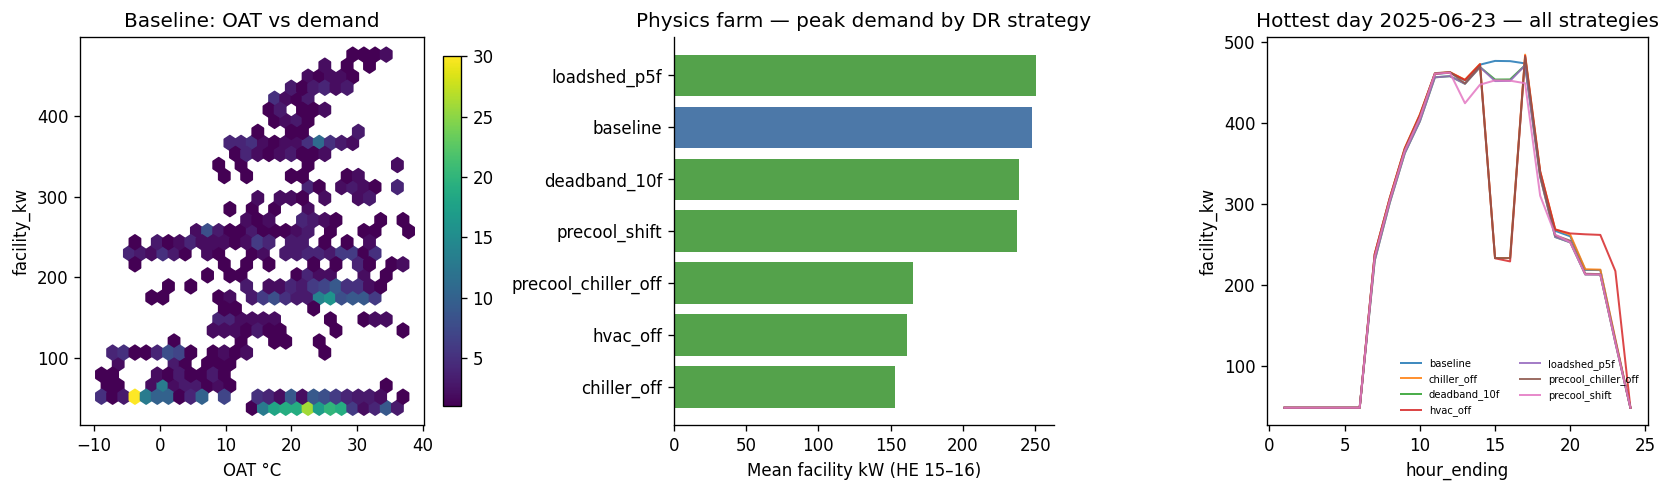

In [3]:
assert PQ_FULL.is_file(), f"Missing {PQ_FULL} - run the DM hourly farm first"
raw = load_farm_frame(PQ_FULL)
assert_no_future_leakage(raw)
df = compile_features(raw)
X, y, groups, cols = matrix_xy(df)
print(
    f"rows={len(df):,}  days={df['day'].nunique()}  "
    f"strategies={df['strategy_id'].nunique()}  features={len(cols)}"
)
display(df[["day", "hour_ending", "strategy_id", "oat_c", "facility_kw"]].head(8))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
base = df[df["strategy_id"] == "baseline"]
hb = axes[0].hexbin(base["oat_c"], base["facility_kw"], gridsize=28, cmap="viridis", mincnt=1)
fig.colorbar(hb, ax=axes[0], fraction=0.046)
axes[0].set_xlabel("OAT °C"); axes[0].set_ylabel("facility_kw")
axes[0].set_title("Baseline: OAT vs demand")
strategy_peak_bars(df, ax=axes[1])
day_hot = df.groupby("day")["oat_c"].max().idxmax()
sub = df[df["day"] == day_hot]
for sid, g in sub.groupby("strategy_id"):
    g = g.sort_values("hour_ending")
    axes[2].plot(g["hour_ending"], g["facility_kw"], lw=1.2, alpha=0.85, label=sid)
axes[2].set_xlabel("hour_ending"); axes[2].set_ylabel("facility_kw")
axes[2].set_title(f"Hottest day {day_hot} — all strategies")
axes[2].legend(fontsize=6, ncol=2, frameon=False)
plt.tight_layout()
fig.savefig(FIG / "01_farm_eda.png", dpi=160, bbox_inches="tight")
plt.show()

## 3 · Family bake-off (who wins?)

Same search spaces as CLI `python -m ml.tune_demand_hourly`.
We score **OOF MAE / RMSE** and peak-window errors, then beat a **lag-1 persistence** baseline.

tune ridge n_iter=20 …


  ridge peak_mae=27.795 vs pers=21.014 params={'alpha': 1000.0}


tune elasticnet n_iter=20 …


  elasticnet peak_mae=28.034 vs pers=21.014 params={'l1_ratio': 0.7, 'alpha': 0.8111308307896873}


tune rf n_iter=20 …


...

  refined extra_trees peak_mae=11.937 params={'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_leaf_nodes': None, 'max_features': 0.8, 'max_depth': 10, 'bootstrap': False}


  re-eval voting peak_mae=14.337


  re-eval stacking peak_mae=12.812


🏆 champion: extra_trees
best_params: {
  "n_estimators": 200,
  "min_samples_split": 5,
  "min_samples_leaf": 1,
  "max_leaf_nodes": null,
  "max_features": 0.8,
  "max_depth": 10,
  "bootstrap": false
}
beat persistence (peak MAE)? True
persistence: {'rmse': 48.118, 'mae': 21.005, 'rmse_peak_14_16': 54.194, 'mae_peak_14_16': 21.014}


,family,mae,rmse,mae_peak_14_16,rmse_peak_14_16
0,extra_trees,15.13,26.85,11.94,21.68
1,stacking,15.54,26.52,12.81,21.51
2,voting,16.04,28.35,14.34,23.84
3,hgb,17.44,29.54,16.08,24.18
4,gbr,17.40,29.45,16.53,25.47
5,rf,17.27,33.19,16.61,31.54
6,ridge,27.11,44.41,27.79,50.11
7,elasticnet,27.07,44.63,28.03,51.48


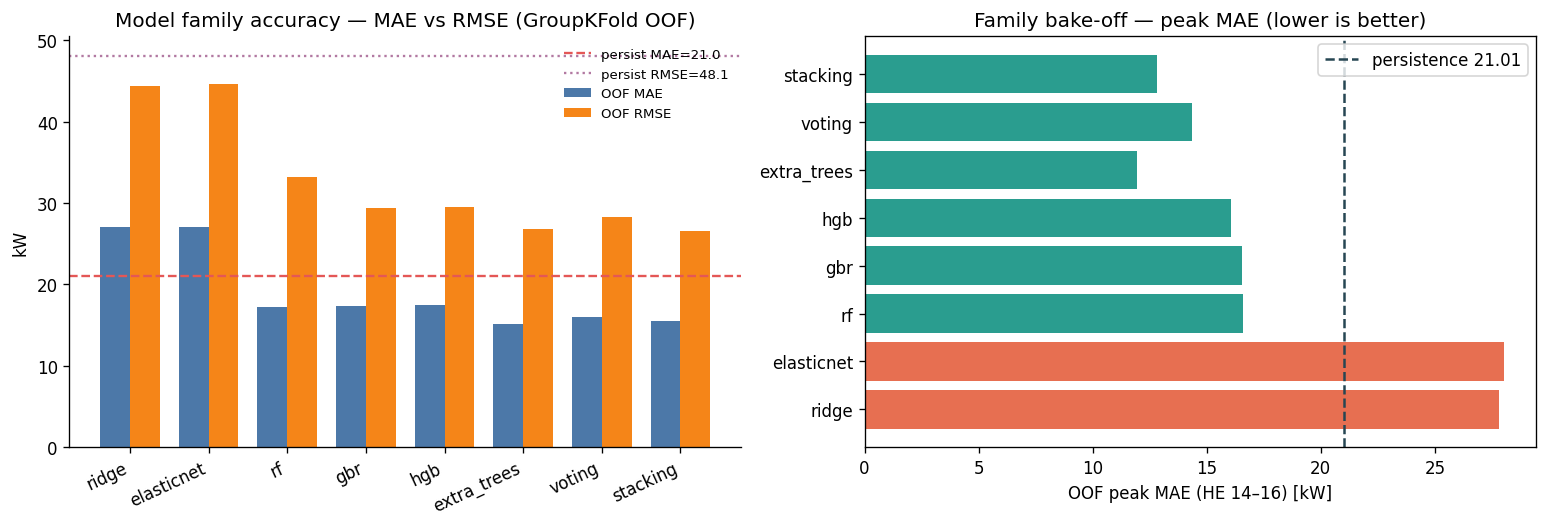

In [4]:
# Moderate iters for a blog re-run; bump for production hunts.
result = tune(df, n_splits=5, n_iter=20, champion_refine_iter=24)
lb = leaderboard_table(result["leaderboard"], result["persistence"])
print("🏆 champion:", result["champion"])
print("best_params:", json.dumps(result["best_params"], indent=2, default=str))
print("beat persistence (peak MAE)?", result["beat_persistence_peak"])
print("persistence:", {k: round(v, 3) for k, v in result["persistence"].items()})
show = lb.drop(columns=["best_params"]).copy()
for c in show.columns:
    if c != "family":
        show[c] = show[c].map(lambda v: round(float(v), 2))
display(show)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
family_mae_rmse_grouped(result["leaderboard"], result["persistence"], ax=axes[0])
family_cv_mae_bars(result["leaderboard"], result["persistence"]["mae_peak_14_16"], ax=axes[1])
plt.tight_layout()
fig.savefig(FIG / "02_family_bakeoff.png", dpi=160, bbox_inches="tight")
plt.show()

## 4 · ExtraTrees hyperparams — search surface + “loss” trajectory

RandomizedSearchCV does not train with gradient descent, so there is no epoch loss.
The analogue is **CV MAE vs trial** (and running-best), plus a scatter of
`n_estimators` × MAE colored by `max_depth`.

ET best_params: {
  "n_estimators": 300,
  "min_samples_split": 5,
  "min_samples_leaf": 1,
  "max_leaf_nodes": null,
  "max_features": 1.0,
  "max_depth": 10,
  "bootstrap": true
}
ET OOF metrics: {'rmse': 26.864, 'mae': 14.824, 'rmse_peak_14_16': 22.706, 'mae_peak_14_16': 12.02}


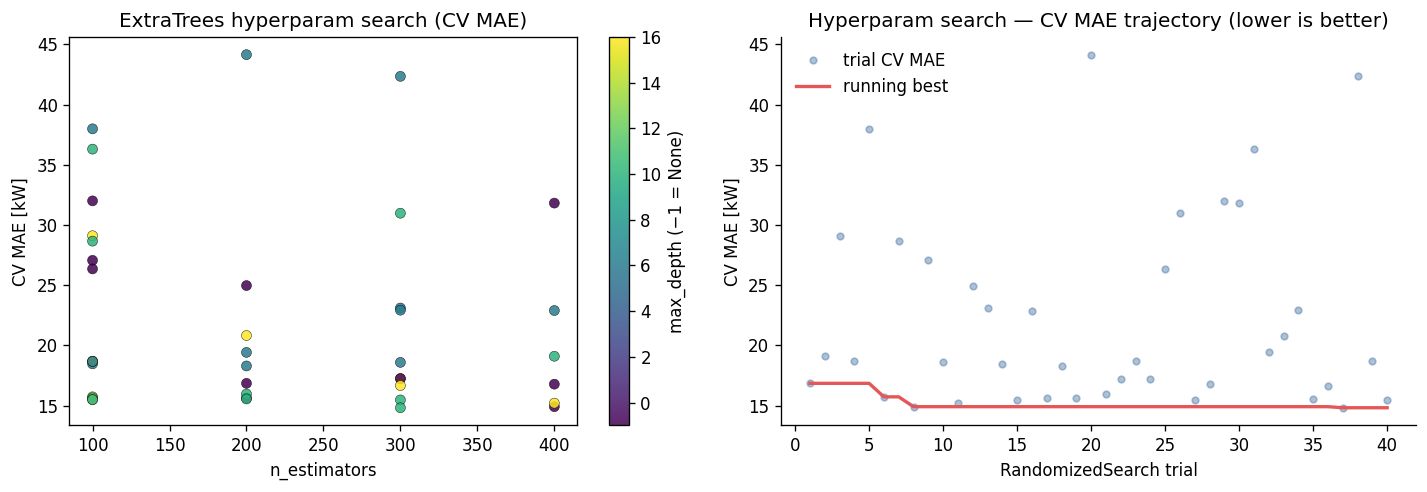

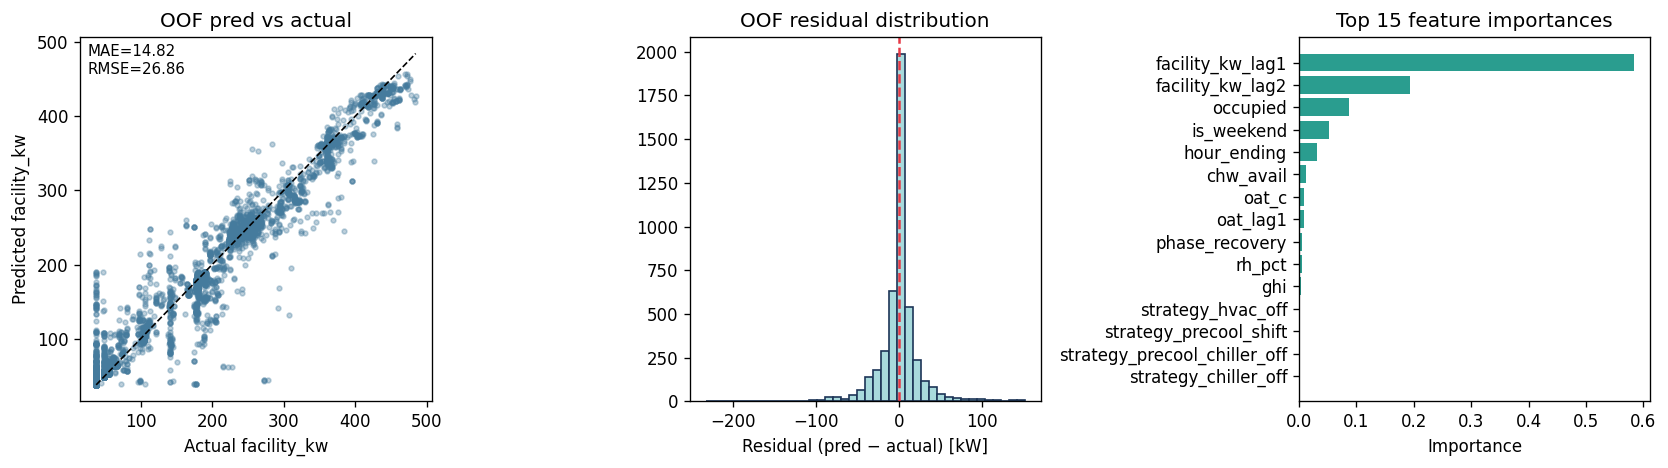

In [5]:
et = run_extratrees_search(df, n_iter=40, n_splits=5)
print("ET best_params:", json.dumps(et["best_params"], indent=2, default=str))
print("ET OOF metrics:", {k: round(v, 3) for k, v in et["oof_metrics"].items()})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
extratrees_search_scatter(et["cv_results"], ax=axes[0])
search_cv_trajectory(et["cv_results"], ax=axes[1])
plt.tight_layout()
fig.savefig(FIG / "03_et_hyperparam_search.png", dpi=160, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
pred_vs_actual(et["y"], et["oof"], ax=axes[0])
residual_hist(et["y"], et["oof"], ax=axes[1])
feature_importance_bar(et["model"], list(et["feature_cols"]), top_n=15, ax=axes[2])
plt.tight_layout()
fig.savefig(FIG / "04_et_diagnostics.png", dpi=160, bbox_inches="tight")
plt.show()

## 5 · Multi-target twin I/O (`demand_hourly_v2`)

Flask / Unity load **v2**: one ExtraTrees model → `facility_kw` + AHU/plant columns.
We show the **shipped** model card metrics, then a light re-tune on the pilot farm
(which has twin I/O columns).

Shipped model_id: demand_hourly_v2 · status: CANDIDATE
Champion family: extra_trees
Hyperparams: {
  "n_estimators": 100,
  "min_samples_split": 5,
  "min_samples_leaf": 1,
  "max_leaf_nodes": null,
  "max_features": 1.0,
  "max_depth": 6,
  "bootstrap": false
}


,target,mae,rmse
20,cw_pump_plr,0.047,0.102
19,chw_pump_plr,0.047,0.102
15,ahu2_fan_plr,0.109,0.166
9,ahu1_fan_plr,0.120,0.196
21,tower_fan_plr,0.142,0.209
10,ahu1_oa_frac,0.176,0.303
22,tower_leaving_c,0.181,0.325
16,ahu2_oa_frac,0.187,0.308
17,chw_supply_c,0.265,0.450
18,chw_return_c,0.769,0.972


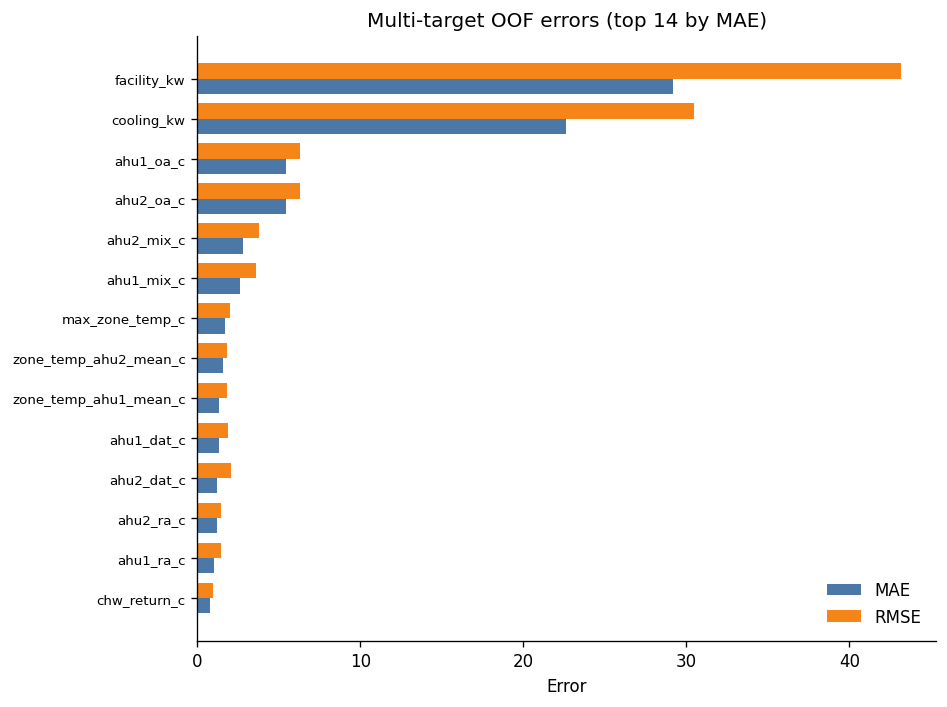

In [6]:
card_path = MODELS / f"{MODEL_STEM_V2}_model_card.json"
tune_path = MODELS / f"{MODEL_STEM_V2}_tuning.json"
shipped = json.loads(card_path.read_text(encoding="utf-8")) if card_path.is_file() else {}
shipped_tune = json.loads(tune_path.read_text(encoding="utf-8")) if tune_path.is_file() else {}

if shipped:
    print("Shipped model_id:", shipped.get("model_id"), "· status:", shipped.get("status"))
    print("Champion family:", shipped.get("champion"))
    print("Hyperparams:", json.dumps(shipped.get("best_params"), indent=2))
    per = (shipped.get("cv_metrics") or {}).get("per_target") or {}
    shipped_tbl = pd.DataFrame(
        [{"target": k, "mae": v["mae"], "rmse": v["rmse"]} for k, v in per.items()]
    ).sort_values("mae")
    shipped_tbl = shipped_tbl.copy()
    shipped_tbl["mae"] = shipped_tbl["mae"].map(lambda v: round(float(v), 3))
    shipped_tbl["rmse"] = shipped_tbl["rmse"].map(lambda v: round(float(v), 3))
    display(shipped_tbl)
    fig, ax = plt.subplots(figsize=(8, 6))
    multitarget_mae_rmse_bars(per, ax=ax, top_n=14)
    plt.tight_layout()
    fig.savefig(FIG / "05_shipped_v2_multitarget.png", dpi=160, bbox_inches="tight")
    plt.show()
else:
    print("No shipped v2 card at", card_path)

pilot rows 360 days 3 targets 23
tune multitarget ExtraTrees n_iter=16 targets=23 …


live multitarget champion params: {
  "n_estimators": 300,
  "min_samples_split": 2,
  "min_samples_leaf": 2,
  "max_leaf_nodes": 128,
  "max_features": 0.8,
  "max_depth": 10,
  "bootstrap": false
}
facility_kw OOF: {'mae': 29.124203205475084, 'rmse': 41.92670086211803}
beat persistence peak? False


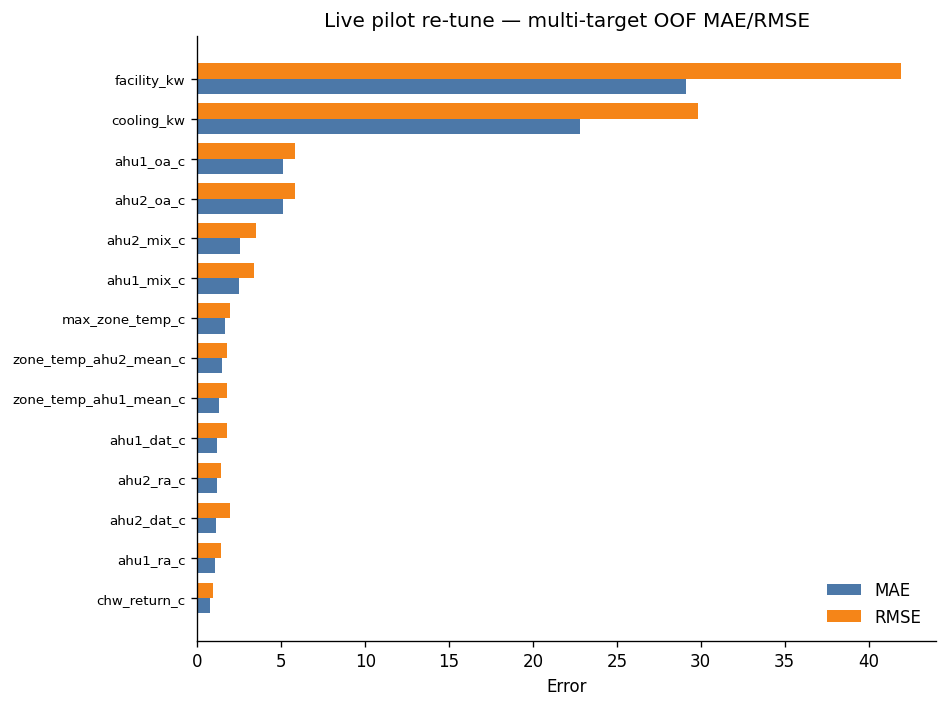

In [7]:
if PQ_PILOT.is_file():
    pilot = compile_features(load_farm_frame(PQ_PILOT))
    tgts = available_target_cols(pilot)
    print("pilot rows", len(pilot), "days", pilot["day"].nunique(), "targets", len(tgts))
    mt = tune_multitarget(pilot, n_splits=min(3, pilot["day"].nunique()), n_iter=16)
    print("live multitarget champion params:", json.dumps(mt["best_params"], indent=2, default=str))
    print("facility_kw OOF:", mt["oof_metrics"]["per_target"].get("facility_kw"))
    print("beat persistence peak?", mt.get("beat_persistence_peak"))
    fig, ax = plt.subplots(figsize=(8, 6))
    multitarget_mae_rmse_bars(mt["oof_metrics"]["per_target"], ax=ax, top_n=14)
    ax.set_title("Live pilot re-tune — multi-target OOF MAE/RMSE")
    plt.tight_layout()
    fig.savefig(FIG / "06_pilot_multitarget_retune.png", dpi=160, bbox_inches="tight")
    plt.show()
else:
    mt = None
    print("pilot farm missing — skip live multitarget")

## 6 · Champion summary (blog TL;DR)

In [8]:
champ_row = lb.iloc[0]
summary = {
    "single_target_champion": result["champion"],
    "single_target_best_params": result["best_params"],
    "single_target_mae": float(champ_row["mae"]),
    "single_target_rmse": float(champ_row["rmse"]),
    "single_target_mae_peak_14_16": float(champ_row["mae_peak_14_16"]),
    "beat_persistence_peak": bool(result["beat_persistence_peak"]),
    "extratrees_best_params": et["best_params"],
    "extratrees_oof": et["oof_metrics"],
    "n_features": len(FEATURE_COLS),
    "n_targets_v2": len(TARGET_COLS),
    "shipped_v2_champion": shipped.get("champion"),
    "shipped_v2_params": shipped.get("best_params"),
    "shipped_v2_facility_kw": (shipped.get("cv_metrics") or {}).get("per_target", {}).get("facility_kw"),
    "honesty": "ENERGYPLUS_SIMULATED CANDIDATE — not BAS-validated",
}
print(json.dumps(summary, indent=2, default=str))
(FIG / "champion_summary.json").write_text(json.dumps(summary, indent=2, default=str) + "\n", encoding="utf-8")
print("wrote", FIG / "champion_summary.json")

{
  "single_target_champion": "extra_trees",
  "single_target_best_params": {
    "n_estimators": 200,
    "min_samples_split": 5,
    "min_samples_leaf": 1,
    "max_leaf_nodes": null,
    "max_features": 0.8,
    "max_depth": 10,
    "bootstrap": false
  },
  "single_target_mae": 15.13489601174608,
  "single_target_rmse": 26.847172224978287,
  "single_target_mae_peak_14_16": 11.937305868705085,
  "beat_persistence_peak": true,
  "extratrees_best_params": {
    "n_estimators": 300,
    "min_samples_split": 5,
    "min_samples_leaf": 1,
    "max_leaf_nodes": null,
    "max_features": 1.0,
    "max_depth": 10,
    "bootstrap": true
  },
  "extratrees_oof": {
    "rmse": 26.864478475122112,
    "mae": 14.823596578226566,
    "rmse_peak_14_16": 22.706495914498998,
    "mae_peak_14_16": 12.020169339991863
  },
  "n_features": 29,
  "n_targets_v2": 23,
  "shipped_v2_champion": "extra_trees",
  "shipped_v2_params": {
    "n_estimators": 100,
    "min_samples_split": 5,
    "min_samples_leaf"

## 7 · Optional dump (off by default)

Production Flask already serves `demand_hourly_v2`. Set `DUMP_CHAMPION = True` in
setup only when you intend to overwrite `flask_app/models/`.

In [9]:
if DUMP_CHAMPION:
    from notebook_plots import dump_champion_bundle

    art = dump_champion_bundle(
        result["model"],
        feature_cols=list(result["feature_cols"]),
        champion=result["champion"],
        best_params=result["best_params"],
        oof_metrics=next(e["oof_metrics"] for e in result["leaderboard"] if e["family"] == result["champion"]),
        n_rows=result["n_rows"],
        n_days=result["n_days"],
        training_parquet=PQ_FULL,
        out_dir=MODELS,
        leaderboard=result["leaderboard"],
        persistence=result["persistence"],
    )
    print("dumped", art)
else:
    print("DUMP_CHAMPION=False — left flask_app/models/demand_hourly_v2 untouched.")

DUMP_CHAMPION=False — left flask_app/models/demand_hourly_v2 untouched.


## Blog embeds (PNG exports)

Same charts written to `notebooks/figures/` for markdown/blog hotlinks.

## Blog figure gallery (embedded)

01_farm_eda.png ok


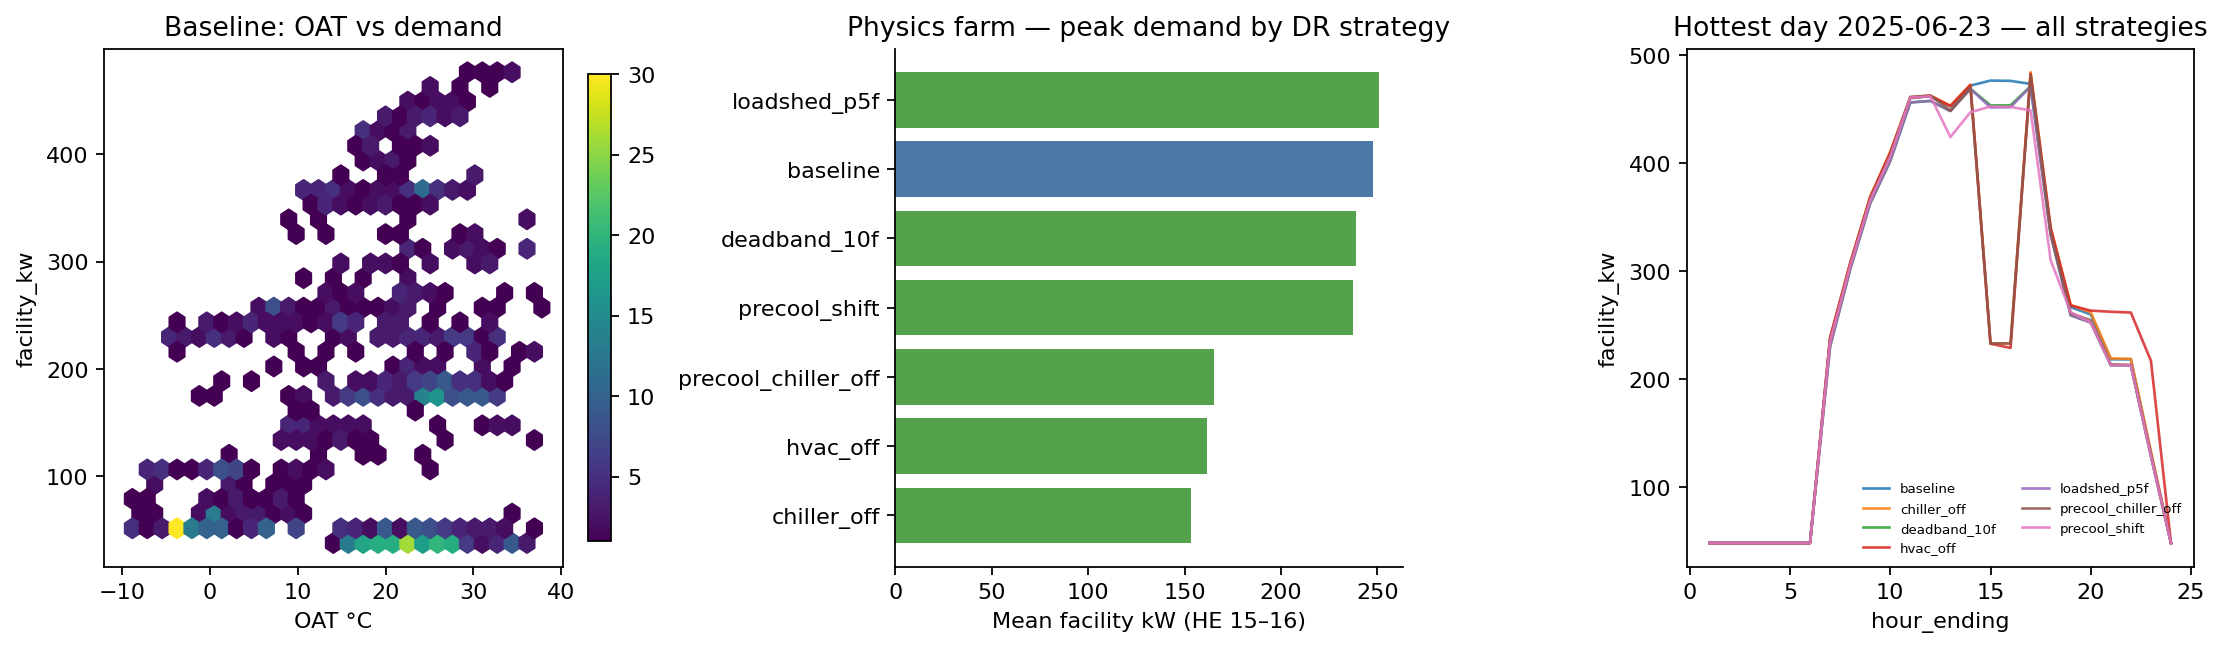

02_family_bakeoff.png ok


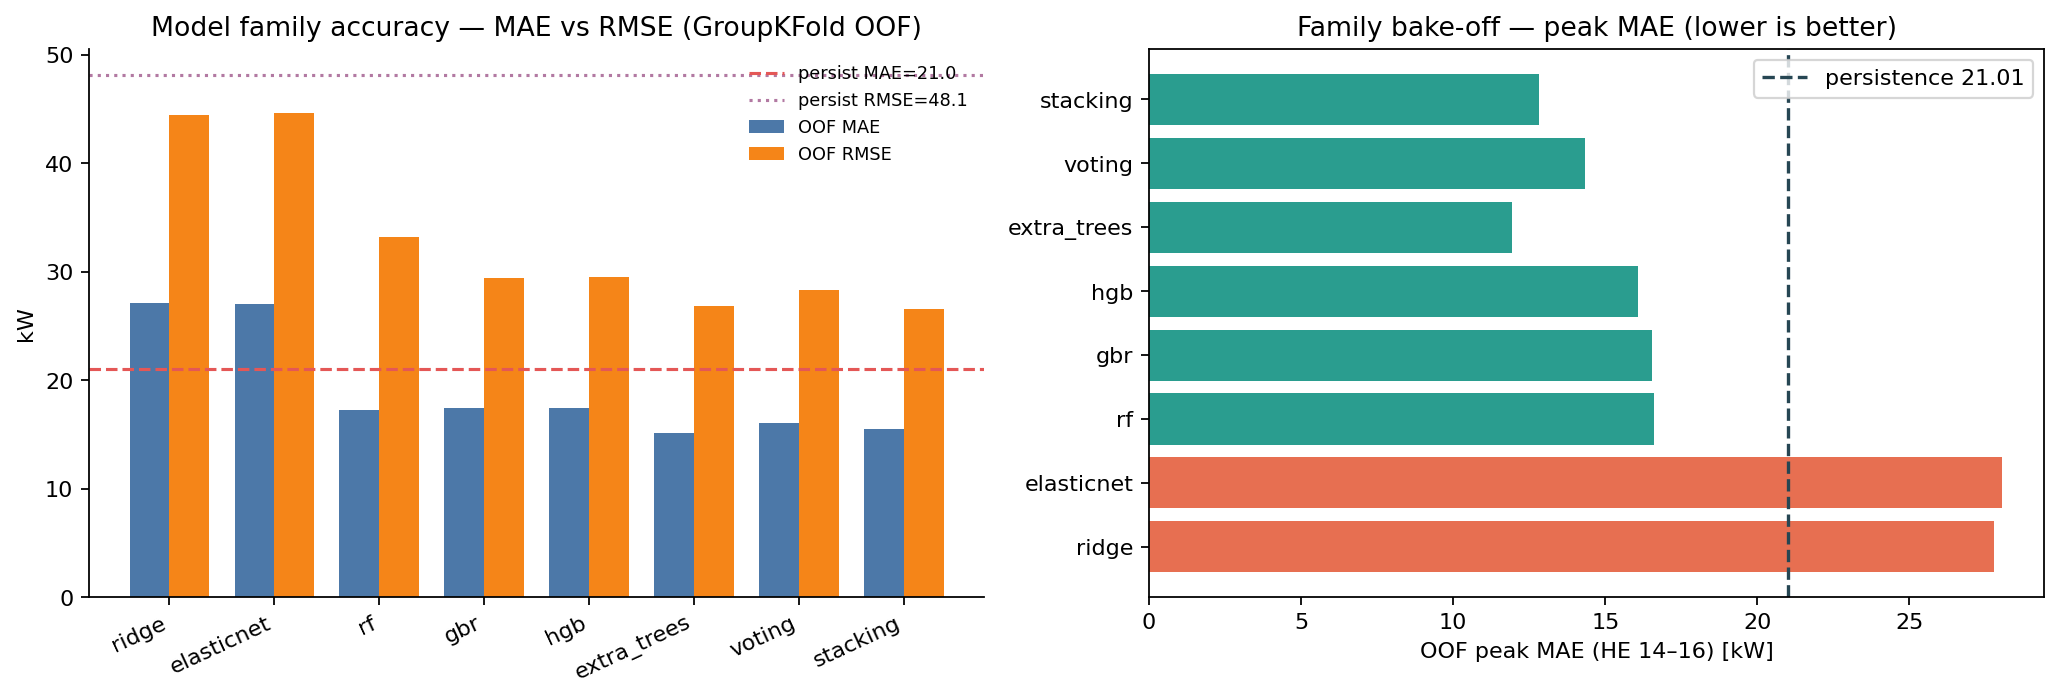

03_et_hyperparam_search.png ok


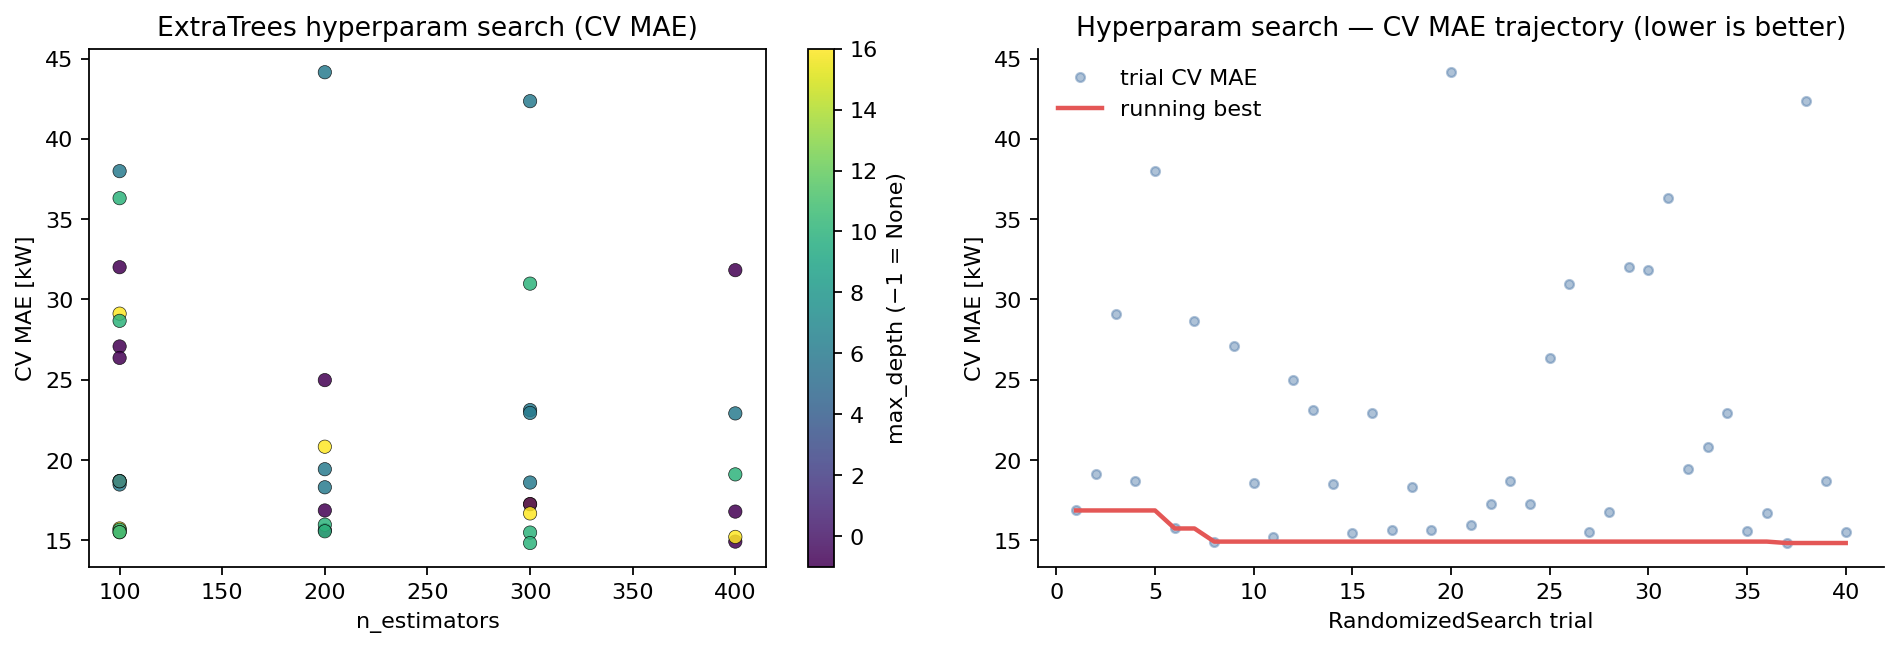

04_et_diagnostics.png ok


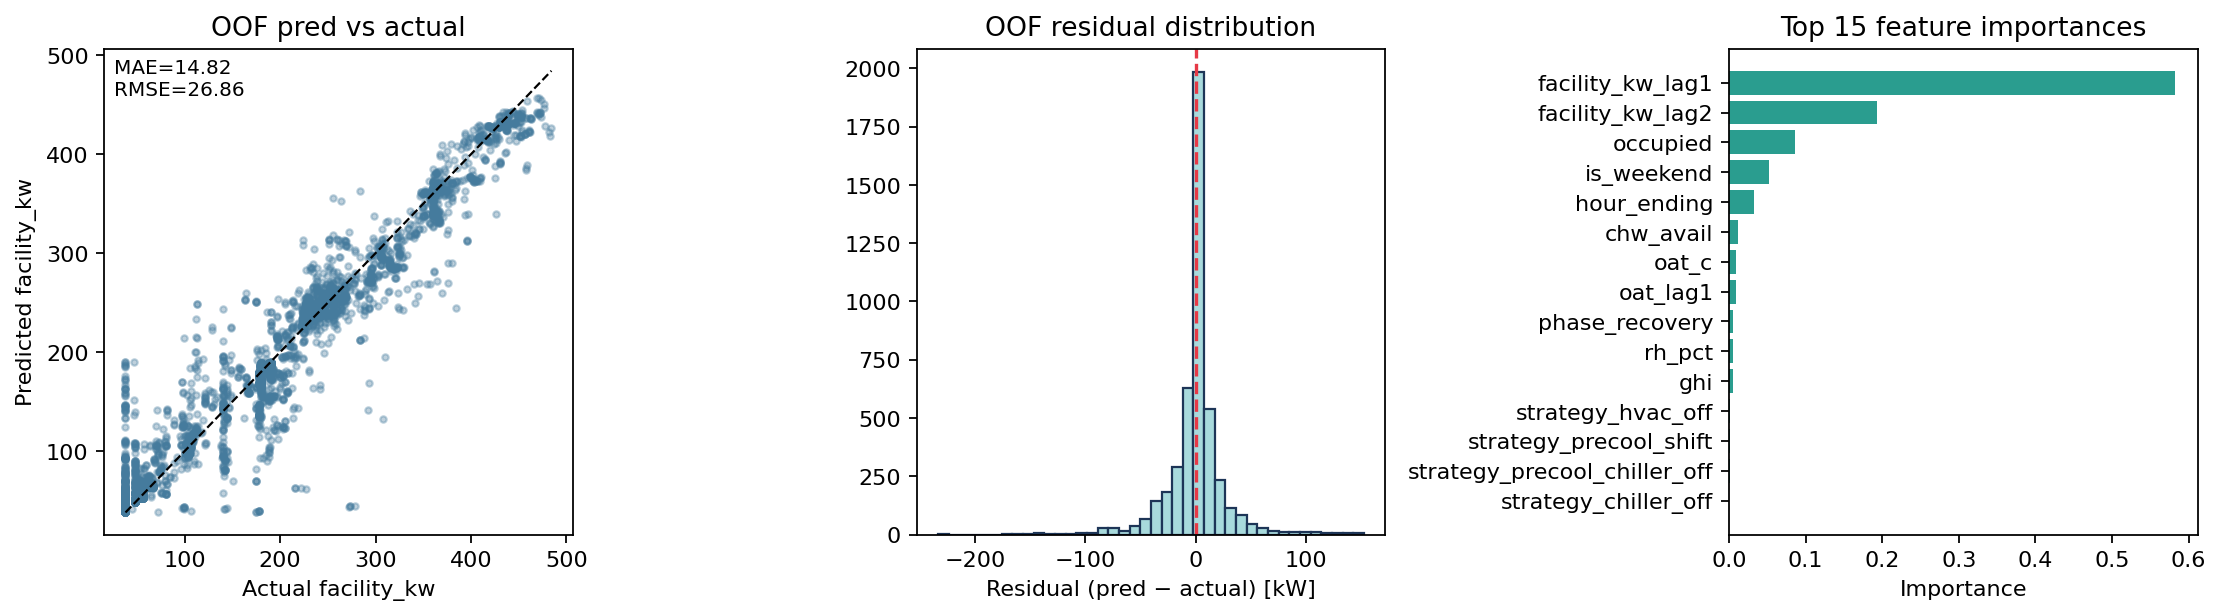

05_shipped_v2_multitarget.png ok


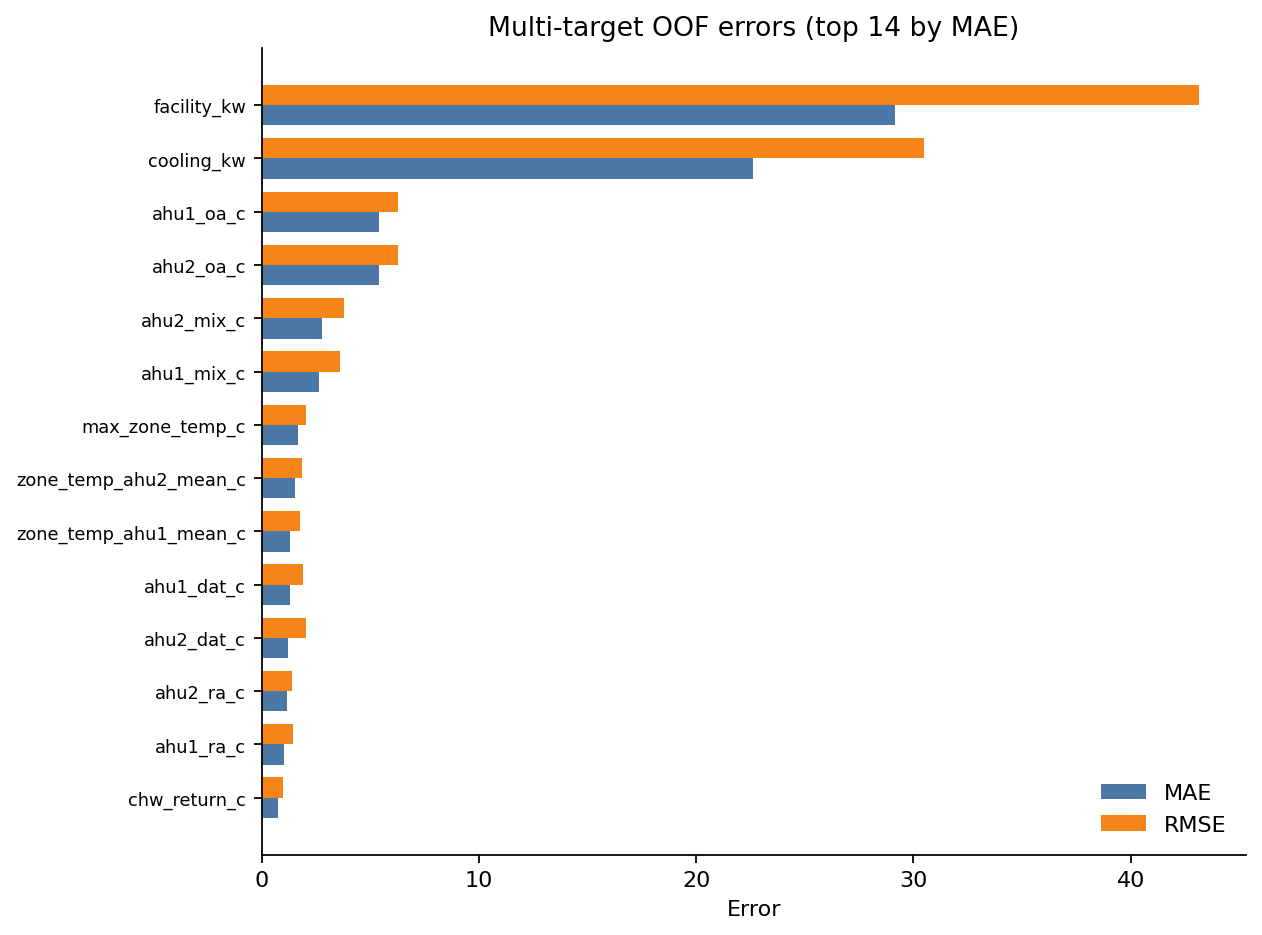

06_pilot_multitarget_retune.png ok


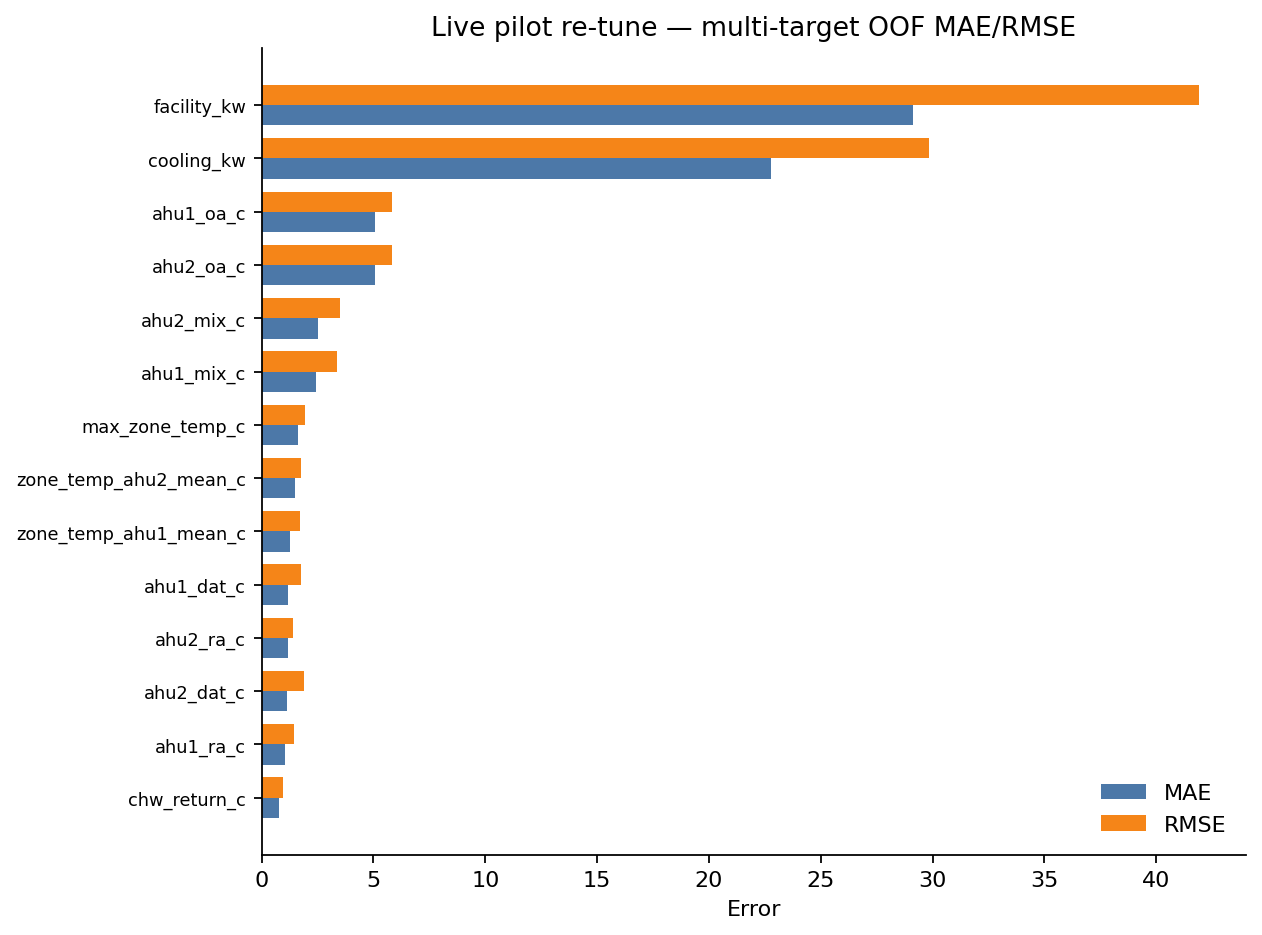

In [10]:
# Force-embed PNG gallery for GitHub rendering
for name in [
    '01_farm_eda.png','02_family_bakeoff.png','03_et_hyperparam_search.png',
    '04_et_diagnostics.png','05_shipped_v2_multitarget.png','06_pilot_multitarget_retune.png'
]:
    p = FIG / name
    print(p.name, 'ok' if p.is_file() else 'MISSING')
    if p.is_file():
        display(Image(filename=str(p)))


## Takeaways

- **Explainers** = weather + occupancy + DR knobs + same-day lags (29 cols).
- **Targets** = `facility_kw` (v1) or 23 twin I/O columns (v2 ExtraTrees).
- **Bake-off** uses GroupKFold-by-day; champion must beat lag-1 persistence on peak HE.
- **Hyperparams** are in the leaderboard / shipped model card (`best_params`).
- **“Loss” plot** = CV MAE trajectory across RandomizedSearch trials.
- Ship via `python tools/pack_pa_bundle.py` (WebGL + models ≤ 100 MiB PA upload).

Figures also land in `notebooks/figures/` for blog embeds.